# Modelos de Aprendizado de Máquina
## Análise de Dados de Compliance Pública - Tese de MBA

**Objetivo:** Construir modelos preditivos para análise de compliance:
- Modelos de regressão (prever taxa de sanções)
- Modelos de classificação (risco de compliance alto/baixo)
- Análise de importância de features
- Avaliação e comparação de modelos

## Passo a passo (estilo aula)

1. Pacotes e configuração do ambiente
2. Reprodutibilidade
3. Carregamento dos dados
4. Blocos de análise
5. Resumo e interpretação


# Pacotes


In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from src.analysis.data_loader import GoldDataLoader

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)
pd.set_option('display.float_format', '{:.4f}'.format)


In [2]:
import matplotlib as mpl
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.limits'] = (-99, 99)


# Reprodutibilidade


In [3]:
import os
import random

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

print(f"Semente de reprodutibilidade fixada em {SEED}")


Semente de reprodutibilidade fixada em 42


In [4]:
import json as _json

_rtcfg_path = os.path.join('..', 'config', 'runtime_config.json')
if os.path.exists(_rtcfg_path):
    with open(_rtcfg_path) as _f:
        _rtcfg = _json.load(_f)
else:
    _rtcfg = {}

S3_BUCKET_NAME = os.environ.get('S3_BUCKET_NAME', _rtcfg.get('aws', {}).get('s3_bucket_name', ''))
AWS_PROFILE = os.environ.get('AWS_PROFILE', _rtcfg.get('aws', {}).get('profile', None))


## 1. Carregar e Preparar Dados

In [5]:
loader = GoldDataLoader(
    bucket_name=S3_BUCKET_NAME,
    aws_profile=AWS_PROFILE
)

df = loader.load_dataset('analysis_compliance')
print(f"Carregados {len(df)} observações")
df.head()


2026-04-08 19:22:42,933 - INFO - Found credentials in shared credentials file: ~/.aws/credentials
2026-04-08 19:22:43,076 - INFO - 📥 Loading analysis_compliance from S3: gold/analysis_compliance/data.parquet
2026-04-08 19:22:43,622 - INFO - ✅ Loaded 27 records, 20 columns


Carregados 27 observações


,state_code,state_name,region_code,region_name,n_municipalities,population,avg_literacy_rate,avg_income,n_sanctions,n_sanctions_ceis,n_sanctions_cnep,n_sanctions_cepim,sanctions_per_100k,log_population,log_income,is_norte,is_nordeste,is_sudeste,is_sul,is_centro_oeste
0,11,Rondônia,1,Norte,52,1581196,91.2900,1211.9600,499,496,3,0,31.5584,14.2737,7.1000,1,0,0,0,0
1,12,Acre,1,Norte,22,830018,83.4100,778.4900,115,115,0,0,13.8551,13.6292,6.6574,1,0,0,0,0
2,13,Amazonas,1,Norte,62,3941613,86.9600,625.4400,217,214,3,0,5.5054,15.1871,6.4385,1,0,0,0,0
3,14,Roraima,1,Norte,15,636707,86.7000,724.2000,125,125,0,0,19.6323,13.3641,6.5851,1,0,0,0,0
4,15,Pará,1,Norte,144,8120131,87.8400,764.4600,351,349,2,0,4.3226,15.9099,6.6392,1,0,0,0,0


In [6]:
feature_cols = ['log_income', 'avg_literacy_rate', 'log_population', 
                'n_municipalities', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']

X = df[feature_cols].copy()
y_regression = df['sanctions_per_100k'].copy()

print(f"Formato das features: {X.shape}")
print(f"Formato do alvo: {y_regression.shape}")
print(f"\nFeatures: {list(X.columns)}")


Formato das features: (27, 8)
Formato do alvo: (27,)

Features: ['log_income', 'avg_literacy_rate', 'log_population', 'n_municipalities', 'is_norte', 'is_nordeste', 'is_sul', 'is_centro_oeste']


## 2. Modelos de Regressão - Prever Taxa de Sanções

### 2.1 Divisão Treino-Teste

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.25, random_state=42
)

print(f"Conjunto de treino: {len(X_train)} amostras")
print(f"Conjunto de teste: {len(X_test)} amostras")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


Conjunto de treino: 20 amostras
Conjunto de teste: 7 amostras


### 2.2 Treinamento e Comparação de Modelos

In [8]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'Decision Tree': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
}

results = []

for name, model in models.items():
    print(f"Treinando {name}...")
    
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

results_df = pd.DataFrame(results).sort_values('R²', ascending=False)

print("\n" + "=" * 80)
print("COMPARAÇÃO DE MODELOS DE REGRESSÃO")
print("=" * 80)
display(results_df)


Treinando Linear Regression...
Treinando Ridge...
Treinando Lasso...
Treinando ElasticNet...
Treinando Decision Tree...
Treinando Random Forest...
Treinando Gradient Boosting...

COMPARAÇÃO DE MODELOS DE REGRESSÃO


,Model,RMSE,MAE,R²
3,ElasticNet,6.1374,4.7618,0.5148
1,Ridge,6.2533,4.6835,0.4963
5,Random Forest,7.9133,5.8628,0.1934
2,Lasso,8.0886,6.0324,0.1572
6,Gradient Boosting,8.4311,6.3475,0.0844
0,Linear Regression,8.9277,6.5630,-0.0267
4,Decision Tree,11.3709,9.4430,-0.6655


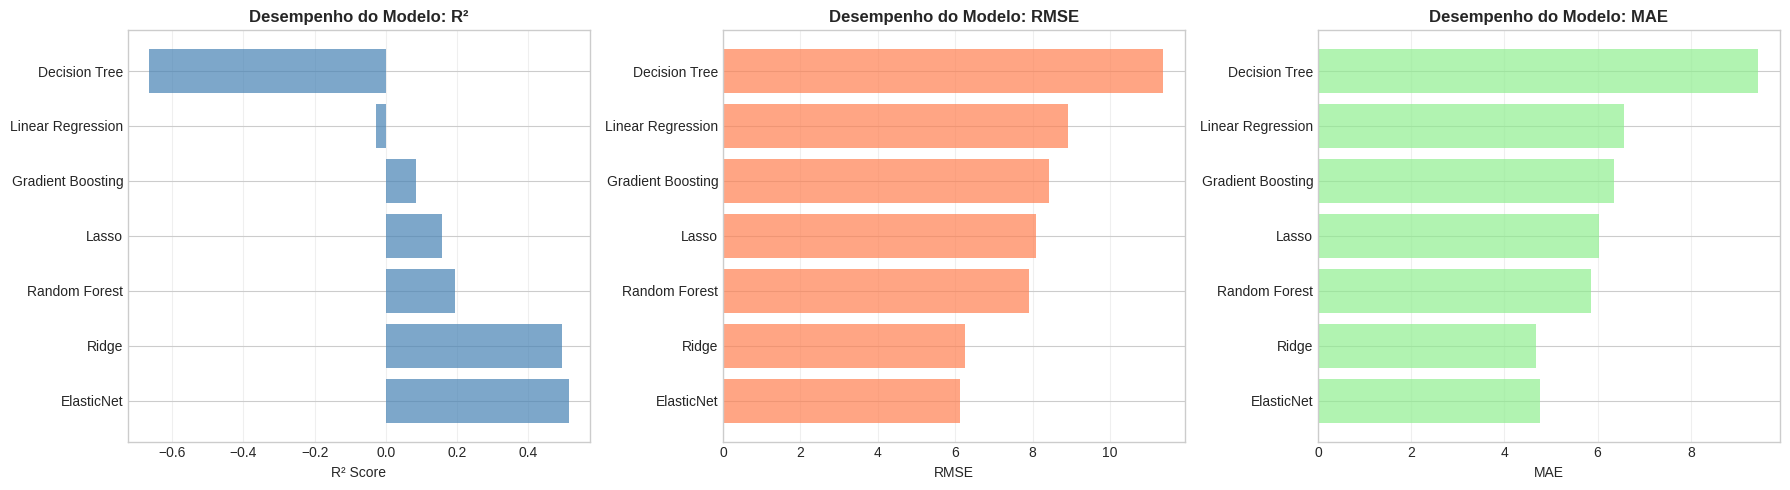

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].barh(results_df['Model'], results_df['R²'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Desempenho do Modelo: R²', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(results_df['Model'], results_df['RMSE'], color='coral', alpha=0.7)
axes[1].set_xlabel('RMSE')
axes[1].set_title('Desempenho do Modelo: RMSE', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

axes[2].barh(results_df['Model'], results_df['MAE'], color='lightgreen', alpha=0.7)
axes[2].set_xlabel('MAE')
axes[2].set_title('Desempenho do Modelo: MAE', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


### 2.3 Melhor Modelo - Análise Detalhada

Melhor Modelo: ElasticNet


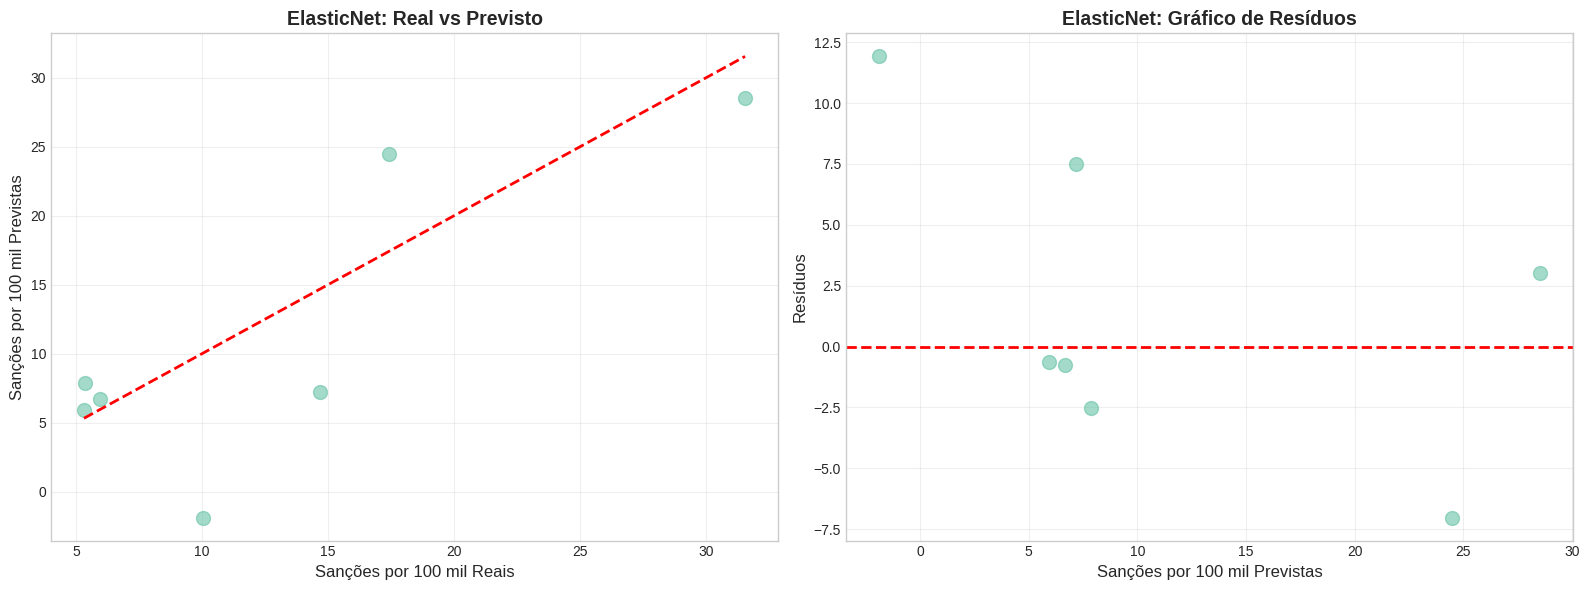

In [10]:
nome_melhor_modelo = results_df.iloc[0]['Model']
melhor_modelo = models[nome_melhor_modelo]

print(f"Melhor Modelo: {nome_melhor_modelo}")
print("=" * 70)

if nome_melhor_modelo in ['Ridge', 'Lasso', 'ElasticNet']:
    y_pred_best = melhor_modelo.predict(X_test_scaled)
else:
    y_pred_best = melhor_modelo.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred_best, alpha=0.6, s=100)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Sanções por 100 mil Reais', fontsize=12)
axes[0].set_ylabel('Sanções por 100 mil Previstas', fontsize=12)
axes[0].set_title(f'{nome_melhor_modelo}: Real vs Previsto', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.6, s=100)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Sanções por 100 mil Previstas', fontsize=12)
axes[1].set_ylabel('Resíduos', fontsize=12)
axes[1].set_title(f'{nome_melhor_modelo}: Gráfico de Resíduos', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.4 Importância de Features (Modelos Baseados em Árvore)

Importância das Features (Random Forest)


,Feature,Importância
0,log_income,0.4318
1,avg_literacy_rate,0.2645
2,log_population,0.1498
3,n_municipalities,0.1281
6,is_sul,0.0120
7,is_centro_oeste,0.0067
5,is_nordeste,0.0057
4,is_norte,0.0014


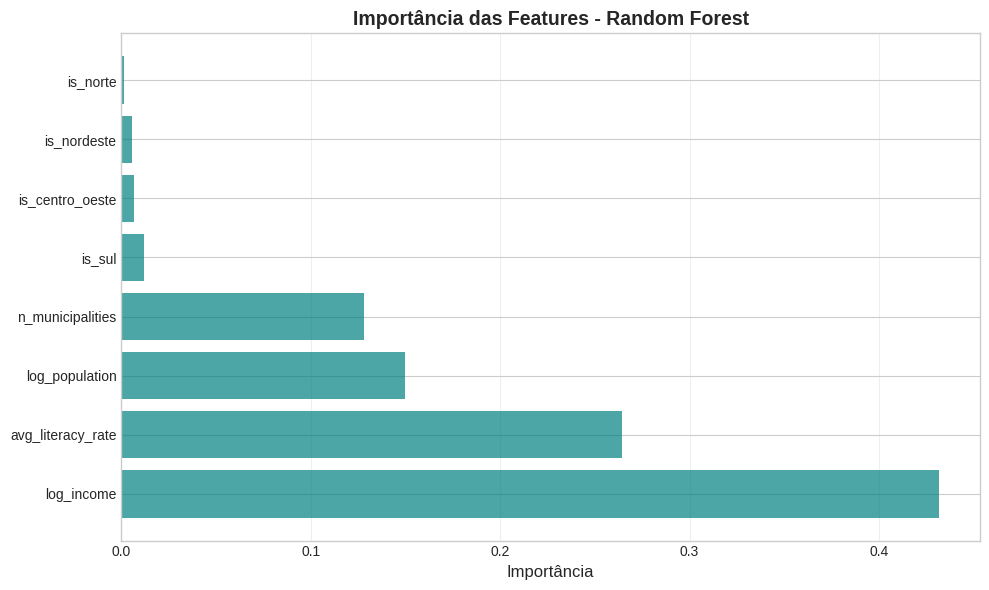

In [11]:
rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importância': rf_model.feature_importances_
}).sort_values('Importância', ascending=False)

print("Importância das Features (Random Forest)")
print("=" * 70)
display(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importância'], color='teal', alpha=0.7)
plt.xlabel('Importância', fontsize=12)
plt.title('Importância das Features - Random Forest', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 2.5 Validação Cruzada

In [12]:
cv_results = []
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in ['Ridge', 'Lasso', 'ElasticNet']:
        X_cv = scaler.fit_transform(X)
    else:
        X_cv = X
    
    scores = cross_val_score(model, X_cv, y_regression, cv=kfold, 
                            scoring='r2', n_jobs=-1)
    
    cv_results.append({
        'Model': name,
        'Média R²': scores.mean(),
        'Std R²': scores.std(),
        'Min R²': scores.min(),
        'Max R²': scores.max()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Média R²', ascending=False)

print("5-Fold Resultados da Validação Cruzada")
print("=" * 80)
display(cv_df)


5-Fold Resultados da Validação Cruzada


,Model,Média R²,Std R²,Min R²,Max R²
3,ElasticNet,0.1410,0.4617,-0.5773,0.8133
1,Ridge,0.0946,0.5098,-0.6865,0.8216
5,Random Forest,-0.0642,0.3964,-0.8145,0.2686
6,Gradient Boosting,-0.0970,0.5515,-1.1632,0.3360
2,Lasso,-0.6100,1.2236,-2.5971,0.8078
0,Linear Regression,-1.1950,1.7697,-3.9702,0.7813
4,Decision Tree,-1.4972,1.2754,-3.3435,-0.0050


## 3. Modelos de Classificação - Risco de Compliance Alto/Baixo

### 3.1 Criar Variável Alvo Binária

In [13]:
median_sanctions = df['sanctions_per_100k'].median()
df['alto_risco'] = (df['sanctions_per_100k'] > median_sanctions).astype(int)

print(f"Mediana sanctions per 100k: {median_sanctions:.2f}")
print(f"\nClass distribution:")
print(df['alto_risco'].value_counts())
print(f"\nClass balance:")
print(df['alto_risco'].value_counts(normalize=True))

y_classification = df['alto_risco'].copy()


Mediana sanctions per 100k: 12.22

Class distribution:
alto_risco
0    14
1    13
Name: count, dtype: int64

Class balance:
alto_risco
0   0.5185
1   0.4815
Name: proportion, dtype: float64


### 3.2 Treinar Modelos de Classificação

In [14]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.25, random_state=42, stratify=y_classification
)

scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

print(f"Conjunto de treino: {len(X_train_clf)} amostras")
print(f"Conjunto de teste: {len(X_test_clf)} amostras")


Conjunto de treino: 20 amostras
Conjunto de teste: 7 amostras


In [15]:
clf_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
}

clf_results = []

for name, model in clf_models.items():
    print(f"\nTraining {name}...")
    
    if name == 'Logistic Regression':
        model.fit(X_train_clf_scaled, y_train_clf)
        y_pred = model.predict(X_test_clf_scaled)
        y_pred_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    else:
        model.fit(X_train_clf, y_train_clf)
        y_pred = model.predict(X_test_clf)
        y_pred_proba = model.predict_proba(X_test_clf)[:, 1]
    
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    accuracy = accuracy_score(y_test_clf, y_pred)
    precision = precision_score(y_test_clf, y_pred)
    recall = recall_score(y_test_clf, y_pred)
    f1 = f1_score(y_test_clf, y_pred)
    roc_auc = roc_auc_score(y_test_clf, y_pred_proba)
    
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    print(f"\n{name} - Classification Report:")
    print(classification_report(y_test_clf, y_pred, target_names=['Baixo Risco', 'Alto Risco']))

clf_results_df = pd.DataFrame(clf_results).sort_values('ROC-AUC', ascending=False)

print("\n" + "=" * 80)
print("COMPARAÇÃO DE MODELOS DE CLASSIFICAÇÃO")
print("=" * 80)
display(clf_results_df)



Training Logistic Regression...

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

 Baixo Risco       1.00      0.25      0.40         4
  Alto Risco       0.50      1.00      0.67         3

    accuracy                           0.57         7
   macro avg       0.75      0.62      0.53         7
weighted avg       0.79      0.57      0.51         7


Training Random Forest...

Random Forest - Classification Report:
              precision    recall  f1-score   support

 Baixo Risco       0.50      0.25      0.33         4
  Alto Risco       0.40      0.67      0.50         3

    accuracy                           0.43         7
   macro avg       0.45      0.46      0.42         7
weighted avg       0.46      0.43      0.40         7


Training Gradient Boosting...

Gradient Boosting - Classification Report:
              precision    recall  f1-score   support

 Baixo Risco       0.33      0.25      0.29         4
  Alto Risco    

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.5714,0.5000,1.0000,0.6667,0.9167
1,Random Forest,0.4286,0.4000,0.6667,0.5000,0.5000
2,Gradient Boosting,0.2857,0.2500,0.3333,0.2857,0.2917


### 3.3 Matrizes de Confusão

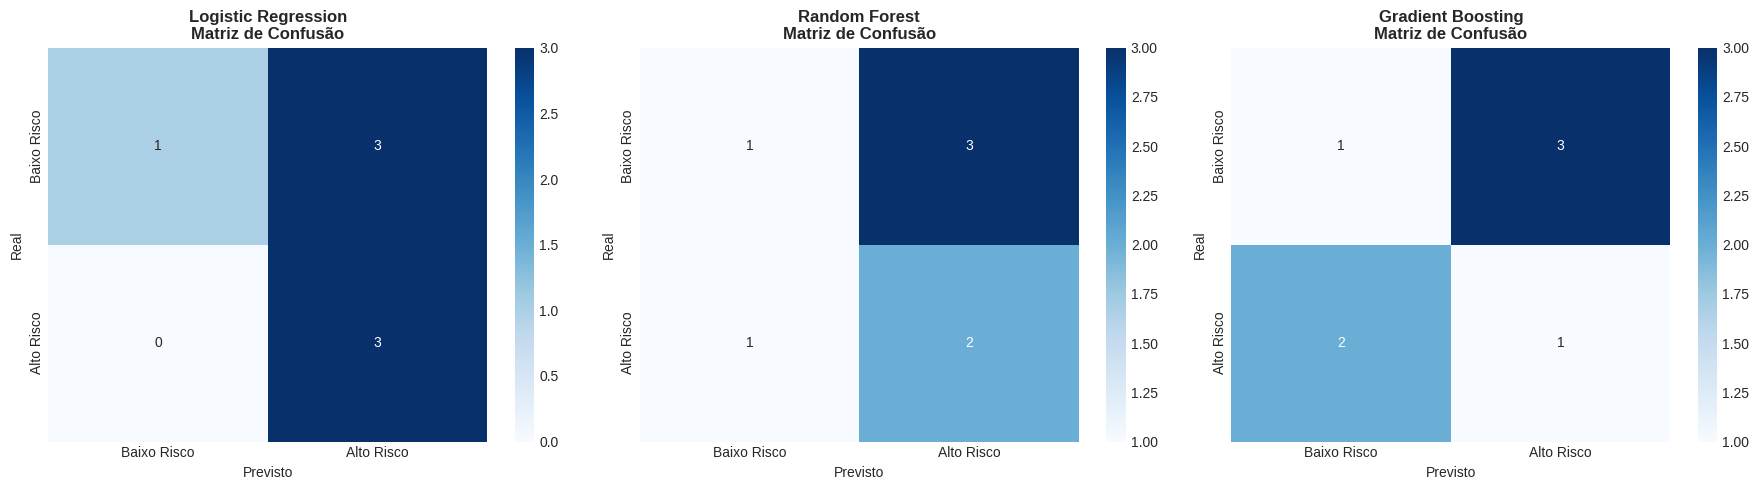

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(clf_models.items()):
    if name == 'Logistic Regression':
        y_pred = model.predict(X_test_clf_scaled)
    else:
        y_pred = model.predict(X_test_clf)
    
    cm = confusion_matrix(y_test_clf, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Baixo Risco', 'Alto Risco'],
                yticklabels=['Baixo Risco', 'Alto Risco'])
    axes[idx].set_title(f'{name}\nMatriz de Confusão', fontweight='bold')
    axes[idx].set_ylabel('Real')
    axes[idx].set_xlabel('Previsto')

plt.tight_layout()
plt.show()


### 3.4 Curvas ROC

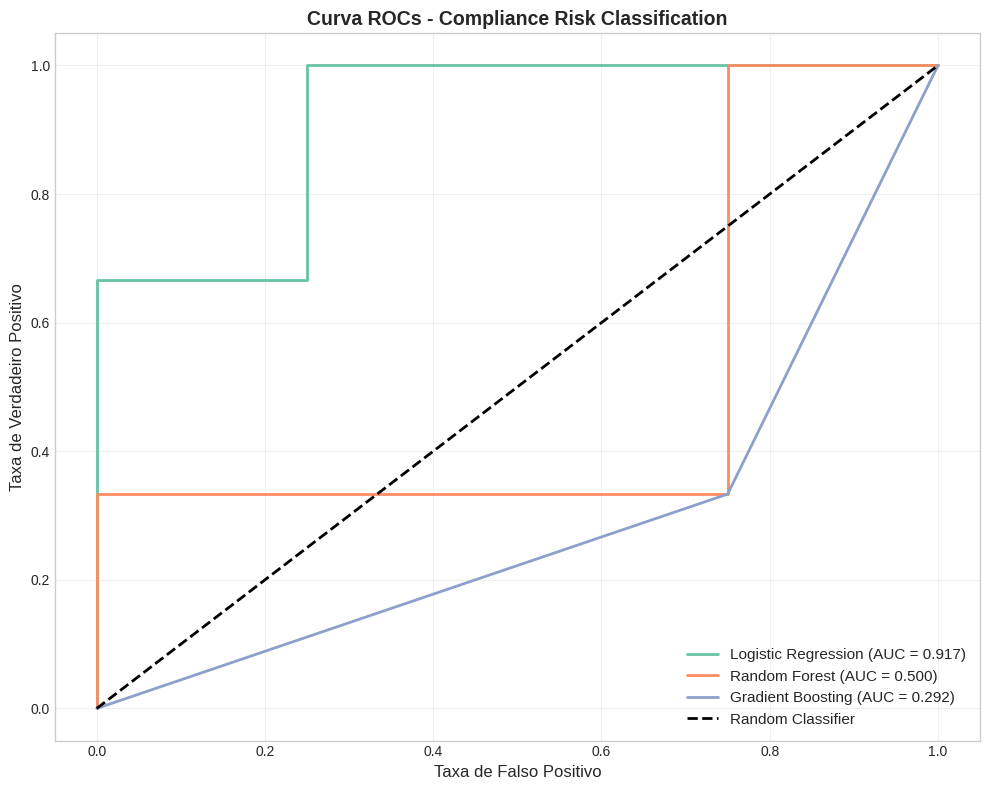

In [17]:
plt.figure(figsize=(10, 8))

for name, model in clf_models.items():
    if name == 'Logistic Regression':
        y_pred_proba = model.predict_proba(X_test_clf_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_test_clf)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test_clf, y_pred_proba)
    auc = roc_auc_score(y_test_clf, y_pred_proba)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=2)
plt.xlabel('Taxa de Falso Positivo', fontsize=12)
plt.ylabel('Taxa de Verdadeiro Positivo', fontsize=12)
plt.title('Curva ROCs - Compliance Risk Classification', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Interpretação do Modelo

### 4.1 Coeficientes da Regressão Logística

Logistic Regression Coefficients


,Feature,Coefficient,Odds Ratio
2,log_population,-1.4419,0.2365
0,log_income,0.8713,2.3901
6,is_sul,0.8418,2.3205
7,is_centro_oeste,-0.5178,0.5958
1,avg_literacy_rate,-0.1808,0.8346
3,n_municipalities,-0.1798,0.8354
5,is_nordeste,0.0898,1.0939
4,is_norte,-0.0078,0.9923


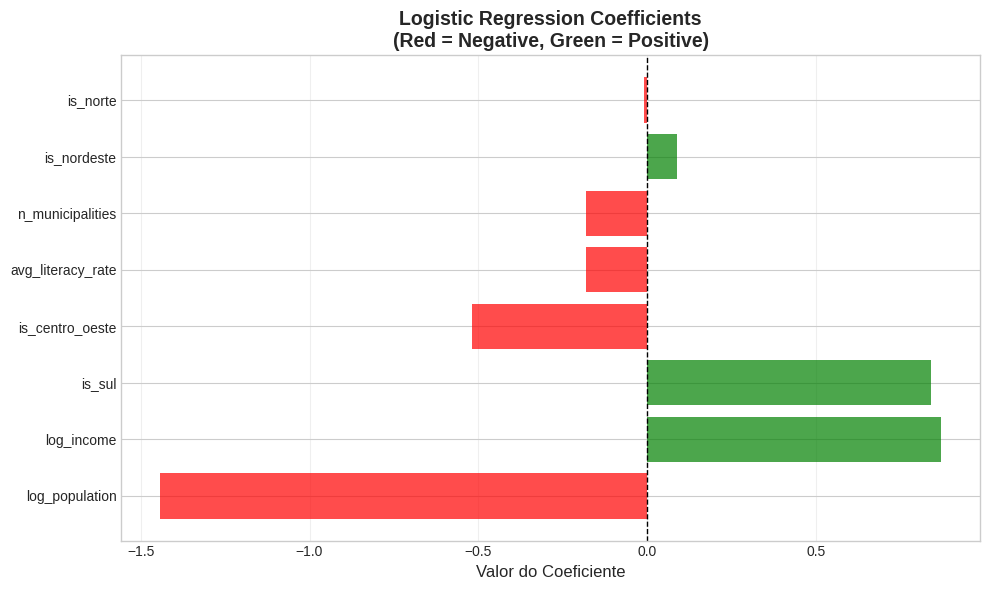

In [18]:
lr_model = clf_models['Logistic Regression']

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', key=abs, ascending=False)

print("Logistic Regression Coefficients")
print("=" * 70)
display(coef_df)

plt.figure(figsize=(10, 6))
colors = ['red' if c < 0 else 'green' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.7)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Valor do Coeficiente', fontsize=12)
plt.title('Logistic Regression Coefficients\n(Red = Negative, Green = Positive)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


### 4.2 Importância de Features (Classificação)

Importância das Features (Random Forest Classifier)


,Feature,Importância
2,log_population,0.3102
0,log_income,0.2043
1,avg_literacy_rate,0.1794
3,n_municipalities,0.1489
6,is_sul,0.0802
7,is_centro_oeste,0.0315
5,is_nordeste,0.0268
4,is_norte,0.0188


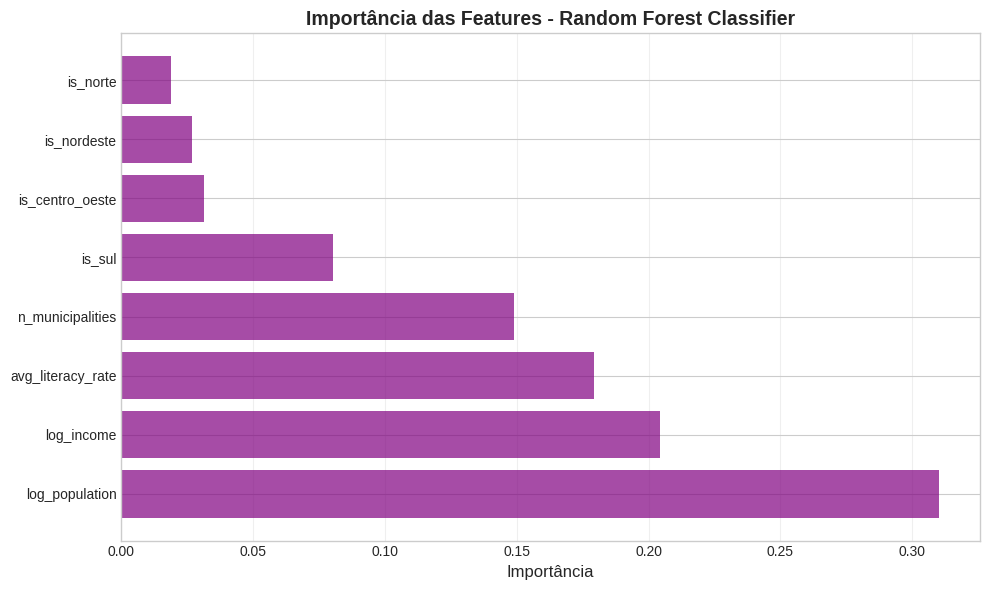

In [19]:
rf_clf = clf_models['Random Forest']

feature_importance_clf = pd.DataFrame({
    'Feature': X.columns,
    'Importância': rf_clf.feature_importances_
}).sort_values('Importância', ascending=False)

print("Importância das Features (Random Forest Classifier)")
print("=" * 70)
display(feature_importance_clf)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_clf['Feature'], feature_importance_clf['Importância'], 
         color='purple', alpha=0.7)
plt.xlabel('Importância', fontsize=12)
plt.title('Importância das Features - Random Forest Classifier', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


## 5. Resumo e Recomendações

### 5.1 Modelos de Regressão
- **Melhor modelo**: ElasticNet, selecionado via validação cruzada entre Regressão Linear, Ridge, Lasso, ElasticNet, Árvore de Decisão, Random Forest e Gradient Boosting.
- **Principais preditores**: Log da renda e dummies regionais (Norte, Nordeste) são as features mais importantes para prever sanções por 100 mil.
- **Importância de features do Random Forest** confirma a renda como preditor dominante, seguida por indicadores de população e alfabetização.
- **Limitação**: Com apenas 27 observações (estados), todos os modelos enfrentam alta variância e generalização limitada.

### 5.2 Modelos de Classificação
- **Alvo binário**: Estados classificados como alto risco (acima da mediana de sanções por 100 mil de 12,22) vs baixo risco.
- **Balanceamento de classes**: Quase balanceado (14 baixo risco, 13 alto risco).
- **Regressão Logística** obteve o melhor desempenho F1 (F1 ponderado = 0,51), mas com recall fraco na classe Baixo Risco (0,25).
- **Random Forest e Gradient Boosting** tiveram desempenho inferior (acurácia 0,43 e 0,29 respectivamente), provavelmente por overfitting no dataset pequeno.
- **Resumo**: O desempenho de classificação é fraco em todos os modelos devido ao tamanho amostral pequeno (n = 27). Resultados devem ser tratados como exploratórios.

### 5.3 Insights Principais
- Renda é consistentemente o preditor mais forte de taxas de sanções em todas as abordagens de modelagem.
- Efeitos regionais (Norte, Nordeste) persistem após controlar por indicadores socioeconômicos, sugerindo fatores institucionais ou de governança em jogo.
- O Distrito Federal permanece como outlier forte que influencia todos os modelos.

### 5.4 Limitações e Ressalvas
- **Amostra pequena** (n = 27): Insuficiente para treinamento robusto de modelos ML. Validação cruzada ajuda, mas não compensa totalmente.
- **Correlação, não causalidade**: Renda mais alta pode refletir maior capacidade institucional de detectar irregularidades, não mais irregularidades de fato.
- **Agregação em nível estadual** mascara variação intra-estadual — análise em nível municipal (NB04) fornece maior granularidade.
- **Sem dimensão temporal**: Modelos são recortes transversais, não preditivos de tendências futuras de sanções.
